# 04 - Entrenamiento y Optimización de Modelos
Comparación de algoritmos, tuning de hiperparámetros y selección del mejor modelo.

In [6]:

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
import joblib
import sys

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import f1_score, classification_report, roc_auc_score
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Cargar datos procesados
X_train = pd.read_csv('../data/processed/X_train.csv')
X_test  = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test  = pd.read_csv('../data/processed/y_test.csv').squeeze()

# Cargar preprocesador
preprocessor = joblib.load('../models/preprocessor.pkl')

print(f"Train: {X_train.shape} | Test: {X_test.shape}")


Train: (40000, 30) | Test: (10000, 30)


In [7]:

# ── 1. Comparación baseline de modelos ────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss', verbosity=0),
    'LightGBM': LGBMClassifier(n_estimators=100, random_state=42, verbose=-1),
}

results = {}
for name, model in models.items():
    pipe = Pipeline([('prep', preprocessor), ('clf', model)])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv,
                              scoring='f1', n_jobs=-1)
    results[name] = {'mean_f1': scores.mean(), 'std_f1': scores.std()}
    print(f"{name:25s}  F1 = {scores.mean():.4f} ± {scores.std():.4f}")

best_model_name = max(results, key=lambda k: results[k]['mean_f1'])
print(f"\n✅ Mejor modelo baseline: {best_model_name} (F1={results[best_model_name]['mean_f1']:.4f})")


Logistic Regression        F1 = 0.6652 ± 0.0080
Random Forest              F1 = 0.7172 ± 0.0066
Gradient Boosting          F1 = 0.6883 ± 0.0049
XGBoost                    F1 = 0.6852 ± 0.0071
LightGBM                   F1 = 0.6918 ± 0.0075

✅ Mejor modelo baseline: Random Forest (F1=0.7172)


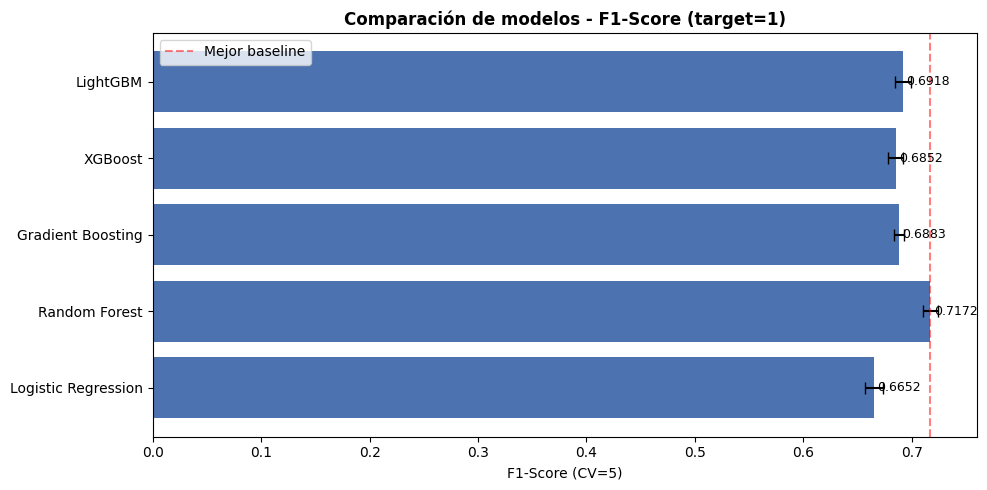

In [8]:

import matplotlib.pyplot as plt

# Visualización de resultados baseline
names = list(results.keys())
means = [results[n]['mean_f1'] for n in names]
stds  = [results[n]['std_f1']  for n in names]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(names, means, xerr=stds, capsize=4,
               color=['#4C72B0']*len(names))
ax.axvline(max(means), color='red', linestyle='--', alpha=0.5, label='Mejor baseline')
ax.set_xlabel('F1-Score (CV=5)')
ax.set_title('Comparación de modelos - F1-Score (target=1)', fontweight='bold')
ax.legend()
for bar, mean in zip(bars, means):
    ax.text(mean + 0.003, bar.get_y() + bar.get_height()/2,
            f'{mean:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('../data/processed/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


In [9]:

# ── 2. Optimización del mejor modelo (LightGBM recomendado) ───────────────
# Ajustar según el modelo que mejor performó en el paso anterior

param_grid_lgbm = {
    'clf__n_estimators': [100, 300, 500],
    'clf__max_depth': [4, 6, 8, -1],
    'clf__learning_rate': [0.01, 0.05, 0.1],
    'clf__num_leaves': [31, 63, 127],
    'clf__min_child_samples': [20, 50, 100],
    'clf__subsample': [0.8, 1.0],
    'clf__colsample_bytree': [0.8, 1.0],
    'clf__scale_pos_weight': [1, 2, 3],  # para desbalance de clases
}

pipe_lgbm = Pipeline([
    ('prep', preprocessor),
    ('clf', LGBMClassifier(random_state=42, verbose=-1))
])

search_lgbm = RandomizedSearchCV(
    pipe_lgbm, param_grid_lgbm,
    n_iter=50, cv=cv, scoring='f1',
    random_state=42, n_jobs=-1, verbose=1
)
search_lgbm.fit(X_train, y_train)

print(f"\nMejor F1 CV (LightGBM): {search_lgbm.best_score_:.4f}")
print(f"Mejores params: {search_lgbm.best_params_}")


Fitting 5 folds for each of 50 candidates, totalling 250 fits

Mejor F1 CV (LightGBM): 0.7276
Mejores params: {'clf__subsample': 1.0, 'clf__scale_pos_weight': 2, 'clf__num_leaves': 127, 'clf__n_estimators': 300, 'clf__min_child_samples': 50, 'clf__max_depth': -1, 'clf__learning_rate': 0.05, 'clf__colsample_bytree': 1.0}


In [10]:

# ── 3. Optimización XGBoost como alternativa ──────────────────────────────
param_grid_xgb = {
    'clf__n_estimators': [100, 300, 500],
    'clf__max_depth': [3, 5, 7],
    'clf__learning_rate': [0.01, 0.05, 0.1],
    'clf__subsample': [0.8, 1.0],
    'clf__colsample_bytree': [0.8, 1.0],
    'clf__scale_pos_weight': [1, 2, 3],
    'clf__gamma': [0, 0.1, 0.5],
}

pipe_xgb = Pipeline([
    ('prep', preprocessor),
    ('clf', XGBClassifier(random_state=42, eval_metric='logloss', verbosity=0))
])

search_xgb = RandomizedSearchCV(
    pipe_xgb, param_grid_xgb,
    n_iter=50, cv=cv, scoring='f1',
    random_state=42, n_jobs=-1, verbose=1
)
search_xgb.fit(X_train, y_train)

print(f"\nMejor F1 CV (XGBoost): {search_xgb.best_score_:.4f}")
print(f"Mejores params: {search_xgb.best_params_}")


Fitting 5 folds for each of 50 candidates, totalling 250 fits

Mejor F1 CV (XGBoost): 0.7253
Mejores params: {'clf__subsample': 0.8, 'clf__scale_pos_weight': 3, 'clf__n_estimators': 300, 'clf__max_depth': 7, 'clf__learning_rate': 0.1, 'clf__gamma': 0.5, 'clf__colsample_bytree': 0.8}


In [11]:

# ── 4. Comparación final y selección ──────────────────────────────────────
candidates = {
    'LightGBM Tuned': search_lgbm,
    'XGBoost Tuned': search_xgb,
}

for name, search in candidates.items():
    y_pred = search.predict(X_test)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, search.predict_proba(X_test)[:,1])
    print(f"\n{name}:")
    print(f"  F1-Score (test): {f1:.4f}")
    print(f"  ROC-AUC  (test): {roc:.4f}")
    print(classification_report(y_test, y_pred, target_names=['No fumador','Fumador']))

# Seleccionar el mejor
best_f1_lgbm = f1_score(y_test, search_lgbm.predict(X_test))
best_f1_xgb  = f1_score(y_test, search_xgb.predict(X_test))

if best_f1_lgbm >= best_f1_xgb:
    best_pipeline = search_lgbm.best_estimator_
    best_name = 'LightGBM'
else:
    best_pipeline = search_xgb.best_estimator_
    best_name = 'XGBoost'

print(f"\n🏆 Modelo seleccionado: {best_name}")



LightGBM Tuned:
  F1-Score (test): 0.7322
  ROC-AUC  (test): 0.8641
              precision    recall  f1-score   support

  No fumador       0.90      0.72      0.80      6334
     Fumador       0.64      0.86      0.73      3666

    accuracy                           0.77     10000
   macro avg       0.77      0.79      0.76     10000
weighted avg       0.80      0.77      0.77     10000


XGBoost Tuned:
  F1-Score (test): 0.7265
  ROC-AUC  (test): 0.8623
              precision    recall  f1-score   support

  No fumador       0.92      0.67      0.78      6334
     Fumador       0.61      0.89      0.73      3666

    accuracy                           0.75     10000
   macro avg       0.76      0.78      0.75     10000
weighted avg       0.80      0.75      0.76     10000


🏆 Modelo seleccionado: LightGBM


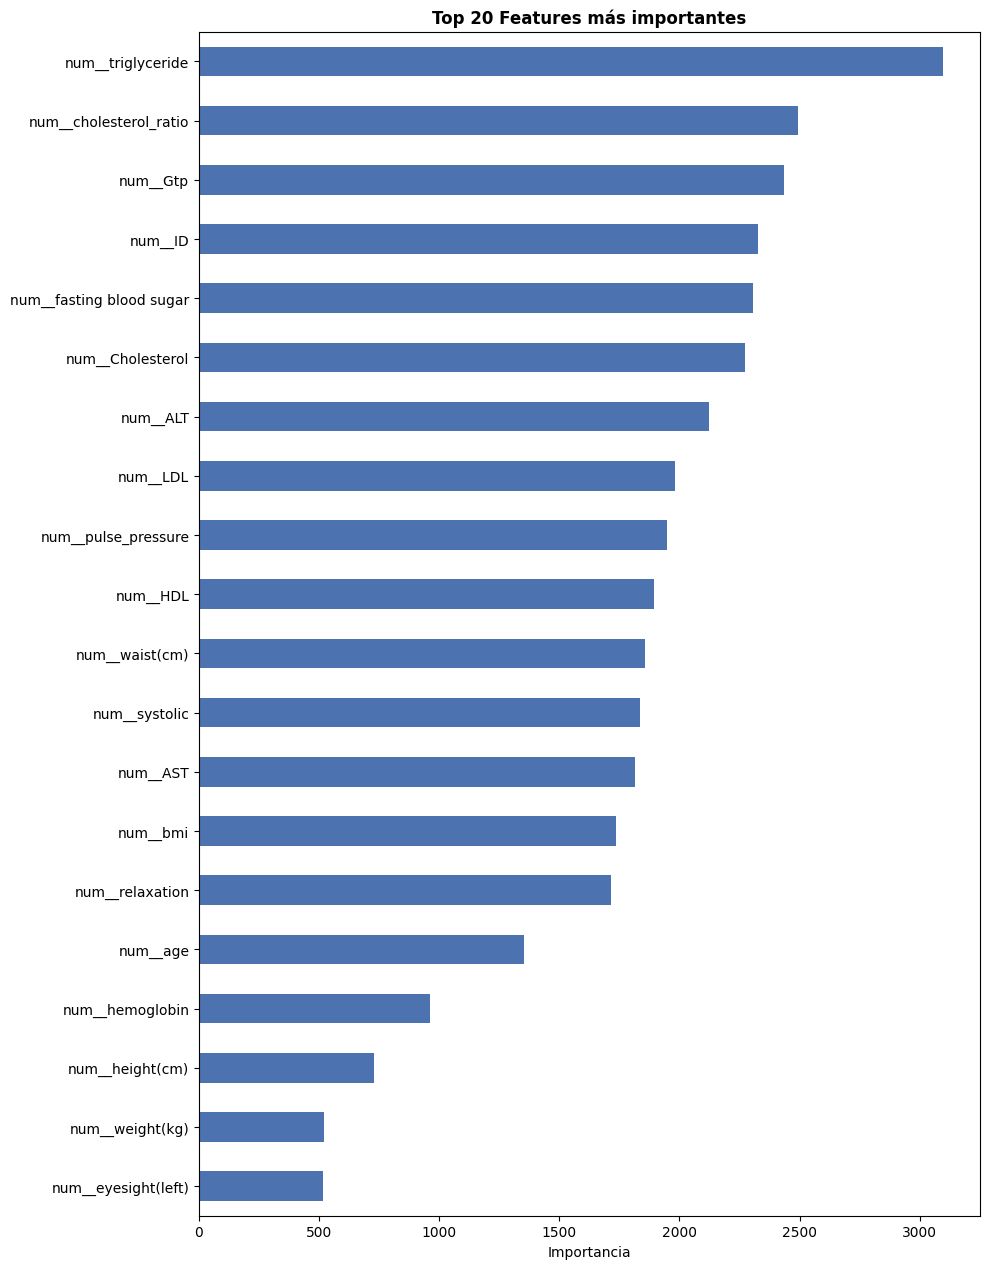

In [12]:

# ── 5. Importancia de features ────────────────────────────────────────────
import matplotlib.pyplot as plt

try:
    clf = best_pipeline.named_steps['clf']
    prep = best_pipeline.named_steps['prep']

    # Obtener nombres de features post-transformación
    feat_names = prep.get_feature_names_out()
    importances = clf.feature_importances_

    feat_imp = pd.Series(importances, index=feat_names).sort_values(ascending=False)

    fig, ax = plt.subplots(figsize=(10, min(20, len(feat_imp)*0.4)))
    feat_imp.head(20).plot(kind='barh', ax=ax, color='#4C72B0')
    ax.invert_yaxis()
    ax.set_title('Top 20 Features más importantes', fontweight='bold')
    ax.set_xlabel('Importancia')
    plt.tight_layout()
    plt.savefig('../data/processed/feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
except Exception as e:
    print(f"No se pudo graficar importancia: {e}")


In [13]:

# ── 6. Guardar modelo final ────────────────────────────────────────────────
joblib.dump(best_pipeline, '../models/best_model.pkl')
print(f"Modelo '{best_name}' guardado en models/best_model.pkl")


Modelo 'LightGBM' guardado en models/best_model.pkl
